In [7]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Librarires loaded sucessfully")

Librarires loaded sucessfully


In [8]:
df = pd.read_csv(r"C:\Users\HP\Documents\FUTURE INTERNS - INTERNSHIP\FUTURE_ML_01\train.csv")

In [9]:
print("Dataset loaded sucessfully")
df

Dataset loaded sucessfully


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [10]:
print(f"Shape: {df.shape}")

Shape: (3000888, 6)


In [11]:
print(f"\nColumns:\n{df.columns.tolist()}")


Columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']


In [12]:
print("\nData Types:")
df.dtypes


Data Types:


id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

In [13]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [14]:
print("\nBasic Statistics:")
df.describe()


Basic Statistics:


,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [15]:
# X input channels with 120 data points each -> model -> X output channels with 16 data points each

In [16]:
len(df.family.unique())

33

In [17]:
len(df.store_nbr.unique())

54

In [18]:
33*54

1782

In [19]:
df['store_family'] = df.apply(lambda x: f"{x['store_nbr']}_{x['family']}", axis=1)

In [20]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,store_family
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1_AUTOMOTIVE
1,1,2013-01-01,1,BABY CARE,0.0,0,1_BABY CARE
2,2,2013-01-01,1,BEAUTY,0.0,0,1_BEAUTY
3,3,2013-01-01,1,BEVERAGES,0.0,0,1_BEVERAGES
4,4,2013-01-01,1,BOOKS,0.0,0,1_BOOKS


In [21]:
df_pivoted = df.pivot(index='date', columns='store_family', values='sales')

In [22]:
df_pivoted

store_family,10_AUTOMOTIVE,10_BABY CARE,10_BEAUTY,10_BEVERAGES,10_BOOKS,10_BREAD/BAKERY,10_CELEBRATION,10_CLEANING,10_DAIRY,10_DELI,...,9_MAGAZINES,9_MEATS,9_PERSONAL CARE,9_PET SUPPLIES,9_PLAYERS AND ELECTRONICS,9_POULTRY,9_PREPARED FOODS,9_PRODUCE,9_SCHOOL AND OFFICE SUPPLIES,9_SEAFOOD
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000,0.0,0.0,0.0,0.000,0.00000,0.000,0.0,0.000000
2013-01-02,3.0,0.0,6.0,396.0,0.0,151.0,0.0,1110.0,101.0,276.0,...,0.0,374.531,482.0,0.0,0.0,651.292,83.00000,0.000,0.0,29.214000
2013-01-03,2.0,0.0,3.0,399.0,0.0,129.0,0.0,970.0,113.0,269.0,...,0.0,400.863,372.0,0.0,0.0,509.496,66.00000,0.000,0.0,25.000000
2013-01-04,2.0,0.0,4.0,460.0,0.0,105.0,0.0,669.0,66.0,92.0,...,0.0,310.878,324.0,0.0,0.0,332.672,57.00000,0.000,0.0,11.000000
2013-01-05,0.0,0.0,3.0,624.0,0.0,112.0,0.0,1093.0,88.0,194.0,...,0.0,447.685,461.0,0.0,0.0,510.919,84.00000,0.000,0.0,28.361000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-11,2.0,0.0,2.0,1459.0,0.0,76.0,5.0,532.0,251.0,269.0,...,5.0,309.245,373.0,11.0,2.0,525.224,112.10000,1453.078,140.0,23.831000
2017-08-12,2.0,0.0,3.0,1332.0,0.0,113.0,5.0,676.0,255.0,276.0,...,2.0,260.298,400.0,7.0,10.0,383.387,129.90399,1419.264,138.0,16.859001
2017-08-13,0.0,0.0,5.0,1526.0,0.0,119.0,6.0,670.0,270.0,251.0,...,3.0,327.206,510.0,2.0,9.0,412.458,105.16900,1693.607,200.0,20.000000


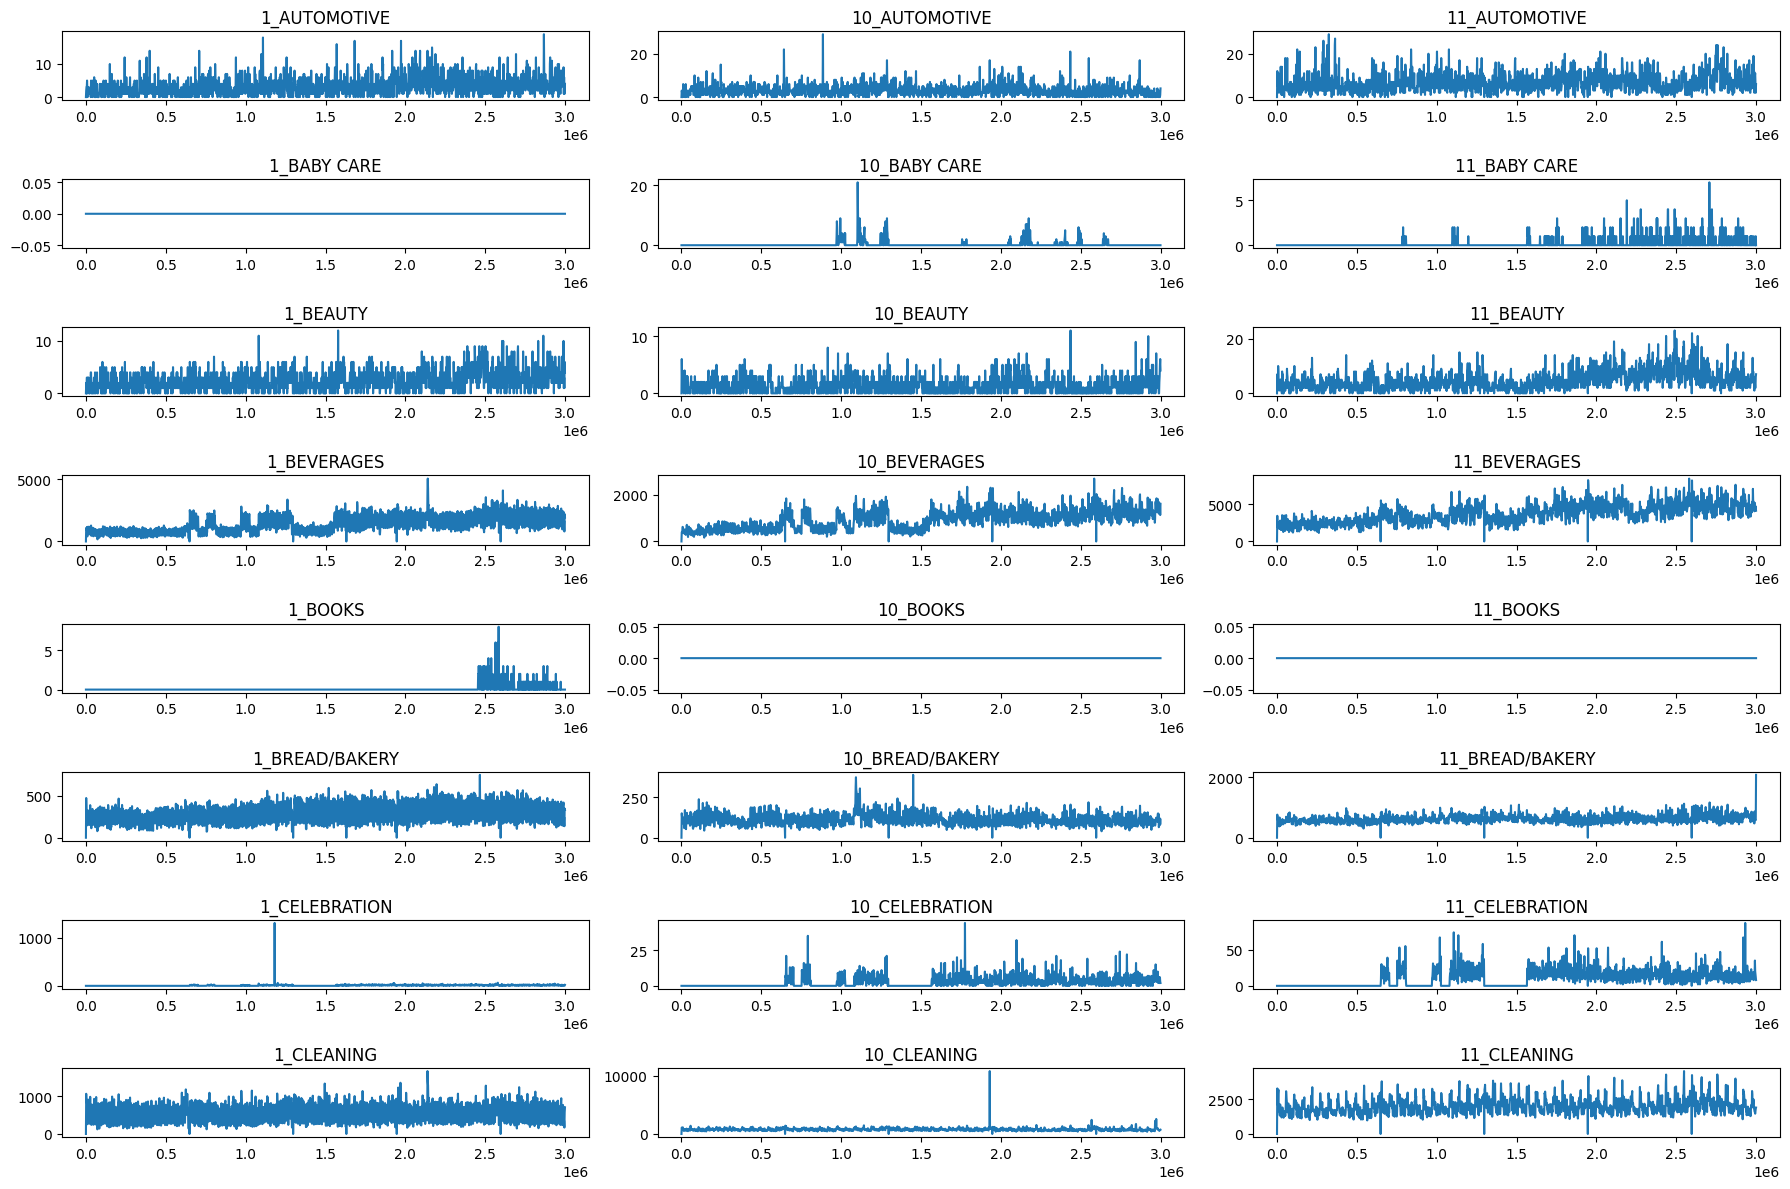

In [23]:
fig, axs = plt.subplots(8, 3, figsize=(18,12))

for i in range(8):
    for j in range(3):
        ax = axs[i][j]
        ax.plot(df[(df.family == df.family.unique()[i]) & (df.store_nbr == df.store_nbr.unique()[j])].sales)
        ax.set_title(f'{df.store_nbr.unique()[j]}_{df.family.unique()[i]}')

plt.tight_layout()

In [24]:
# Scale the data

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_size = int(0.8 * len(df_pivoted))
train_data = df_pivoted.iloc[:train_size]
test_data = df_pivoted.iloc[train_size:]

train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

In [26]:
def create_X_y(data, input_length, output_length):
    X, y = [], []
    
    for i in range(len(data) - input_length - output_length + 1):
        X.append(data[i:i+input_length])
        y.append(data[i+input_length:i+input_length+output_length])
    
    return np.array(X), np.array(y)

In [27]:
X_train, y_train = create_X_y(train_data_scaled, 120, 16)
X_test, y_test = create_X_y(test_data_scaled, 120, 16)

In [28]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1212, 120, 1782) (1212, 16, 1782)
(202, 120, 1782) (202, 16, 1782)


In [29]:
!pip install torch

In [30]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.FloatTensor(X_train).to(device)
X_test_tensor  = torch.FloatTensor(X_test).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
y_test_tensor  = torch.FloatTensor(y_test).to(device)

In [31]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Building and Training Model

In [32]:
import torch.nn as nn
import torch.nn.functional as F

class TCNModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv1d(33*54, 64, kernel_size=3, padding=2, dilation=1)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=4, dilation=2)
        self.conv3 = nn.Conv1d(64, 64, kernel_size=3, padding=8, dilation=3)
        
        self.fc = nn.Linear(64, 16*33*54)
    
    def forward(self, x):
        x = x.transpose(1, 2)
        x = F.relu(self.conv1(x[:,:,:-2]))
        x = F.relu(self.conv2(x[:,:,:-4]))
        x = F.relu(self.conv3(x[:,:,:-8]))

        return self.fc(x[:,:,-1]).view(-1, 16, 33*54)

In [33]:
model = TCNModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [34]:
for epoch in range(30):
    model.train()
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        y_pred = model(X_batch)
        
        loss = torch.sqrt(criterion(y_pred, y_batch))
        loss.backward()
        
        optimizer.step()

        # Average loss
        epoch_loss += loss.item()

    # Print every epoch
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader)}')

Epoch 5, Loss: 0.971018229660235
Epoch 10, Loss: 0.97067864788206
Epoch 15, Loss: 0.9713250728029954
Epoch 20, Loss: 0.9711345653784903
Epoch 25, Loss: 0.971085869952252
Epoch 30, Loss: 0.9711676616417734


In [35]:
model.eval()

with torch.no_grad():
    test_pred = model(X_test_tensor)
    test_loss = torch.sqrt(criterion(test_pred, y_test_tensor))
    print(test_loss)

tensor(172.1758)


### Full Dataset Training

In [36]:
full_data_scaled = scaler.fit_transform(df_pivoted)

X_full, y_full = create_X_y(full_data_scaled, 120, 16)

X_full_tensor = torch.FloatTensor(X_full).to(device)
y_full_tensor  = torch.FloatTensor(y_full).to(device)

full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size=32, shuffle=True)

final_model = TCNModel().to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [37]:
for epoch in range(30):
    final_model.train()
    epoch_loss = 0
    
    for X_batch, y_batch in full_loader:
        optimizer.zero_grad()
        
        y_pred = final_model(X_batch)
        
        loss = torch.sqrt(criterion(y_pred, y_batch))
        loss.backward()
        
        optimizer.step()

        # Average loss
        epoch_loss += loss.item()

    # Print every epoch
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}, Loss: {epoch_loss/len(full_loader)}')

Epoch 5, Loss: 0.9865393091221245
Epoch 10, Loss: 0.9885110842938326
Epoch 15, Loss: 0.9880632770304777
Epoch 20, Loss: 0.9866135242033978
Epoch 25, Loss: 0.9878026344338242
Epoch 30, Loss: 0.9882896031652179


In [38]:
final_model.eval()

with torch.no_grad():
    last_sequence = torch.FloatTensor(full_data_scaled[-120:]).unsqueeze(0).to(device)
    predictions = final_model(last_sequence)

In [39]:
predictions

tensor([[[ 0.0113,  0.0200, -0.0087,  ...,  0.0627, -0.0401, -0.0285],
         [ 0.0138,  0.0222, -0.0082,  ...,  0.0732, -0.0374, -0.0292],
         [ 0.0209,  0.0225, -0.0044,  ...,  0.0697, -0.0361, -0.0320],
         ...,
         [ 0.0154,  0.0192, -0.0125,  ...,  0.0795,  0.0166, -0.0318],
         [ 0.0023,  0.0146,  0.0018,  ...,  0.0785,  0.0191, -0.0352],
         [ 0.0045,  0.0148,  0.0017,  ...,  0.0851,  0.0233, -0.0289]]])

In [40]:
predictions = predictions.cpu().numpy().squeeze(0)
predictions = scaler.inverse_transform(predictions)
predictions = np.maximum(predictions, 0)

In [41]:
predictions

array([[3.1132600e+00, 2.9670185e-01, 1.3606805e+00, ..., 1.0243522e+03,
        5.1583624e+00, 1.6617397e+01],
       [3.1198318e+00, 2.9919171e-01, 1.3613412e+00, ..., 1.0335750e+03,
        5.2178044e+00, 1.6610361e+01],
       [3.1386292e+00, 2.9954684e-01, 1.3667401e+00, ..., 1.0305032e+03,
        5.2472134e+00, 1.6584364e+01],
       ...,
       [3.1238928e+00, 2.9583761e-01, 1.3552716e+00, ..., 1.0391517e+03,
        6.4214330e+00, 1.6586462e+01],
       [3.0892103e+00, 2.9052955e-01, 1.3754014e+00, ..., 1.0382241e+03,
        6.4757414e+00, 1.6553970e+01],
       [3.0952029e+00, 2.9075176e-01, 1.3753556e+00, ..., 1.0440209e+03,
        6.5705547e+00, 1.6613537e+01]], shape=(16, 1782), dtype=float32)

In [42]:
test_df = pd.read_csv(r'C:\Users\HP\Documents\FUTURE INTERNS - INTERNSHIP\FUTURE_ML_01\store-sales-time-series-forecasting\test.csv')

In [43]:
test_df

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9


In [44]:
test_df['store_family'] = test_df.apply(lambda x: f"{x['store_nbr']}_{x['family']}", axis=1)

In [45]:
test_df

,id,date,store_nbr,family,onpromotion,store_family
0,3000888,2017-08-16,1,AUTOMOTIVE,0,1_AUTOMOTIVE
1,3000889,2017-08-16,1,BABY CARE,0,1_BABY CARE
2,3000890,2017-08-16,1,BEAUTY,2,1_BEAUTY
3,3000891,2017-08-16,1,BEVERAGES,20,1_BEVERAGES
4,3000892,2017-08-16,1,BOOKS,0,1_BOOKS
...,...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1,9_POULTRY
28508,3029396,2017-08-31,9,PREPARED FOODS,0,9_PREPARED FOODS
28509,3029397,2017-08-31,9,PRODUCE,1,9_PRODUCE
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9,9_SCHOOL AND OFFICE SUPPLIES


In [46]:
dates = sorted(test_df['date'].unique())

In [47]:
dates

['2017-08-16',
 '2017-08-17',
 '2017-08-18',
 '2017-08-19',
 '2017-08-20',
 '2017-08-21',
 '2017-08-22',
 '2017-08-23',
 '2017-08-24',
 '2017-08-25',
 '2017-08-26',
 '2017-08-27',
 '2017-08-28',
 '2017-08-29',
 '2017-08-30',
 '2017-08-31']

In [48]:
pred_df = pd.DataFrame(predictions, index=dates, columns=df_pivoted.columns)

In [49]:
pred_df

store_family,10_AUTOMOTIVE,10_BABY CARE,10_BEAUTY,10_BEVERAGES,10_BOOKS,10_BREAD/BAKERY,10_CELEBRATION,10_CLEANING,10_DAIRY,10_DELI,...,9_MAGAZINES,9_MEATS,9_PERSONAL CARE,9_PET SUPPLIES,9_PLAYERS AND ELECTRONICS,9_POULTRY,9_PREPARED FOODS,9_PRODUCE,9_SCHOOL AND OFFICE SUPPLIES,9_SEAFOOD
2017-08-16,3.113260,0.296702,1.360680,919.494629,0.000000,113.641289,2.794522,778.404846,261.343506,253.239822,...,1.754570,377.869507,449.363281,3.556718,7.261785,490.712158,90.239754,1024.352173,5.158362,16.617397
2017-08-17,3.119832,0.299192,1.361341,922.378845,0.002760,113.580734,2.803589,779.476318,262.207367,253.414108,...,1.746750,378.607910,451.071808,3.586829,7.266280,492.727753,90.515244,1033.574951,5.217804,16.610361
2017-08-18,3.138629,0.299547,1.366740,921.724426,0.004658,113.726601,2.776942,778.647461,262.049469,253.491989,...,1.732119,377.829834,450.181122,3.584768,7.310033,491.912781,90.268234,1030.503174,5.247213,16.584364
2017-08-19,3.100212,0.293564,1.370540,924.321167,0.000000,113.456039,2.807543,778.999023,262.614594,253.137482,...,1.760549,378.406067,449.791046,3.560370,7.295486,491.176483,90.264565,1027.096802,5.388128,16.602182
2017-08-20,3.118576,0.294149,1.356524,924.066345,0.001174,113.508263,2.794727,778.299072,261.699463,252.916489,...,1.760414,377.913788,450.341583,3.559195,7.301423,491.289612,90.521461,1034.328857,5.587988,16.604784
2017-08-21,3.102659,0.293737,1.368404,921.666077,0.000000,113.340820,2.794373,778.423767,263.194550,252.937836,...,1.744842,377.806183,449.377472,3.616866,7.296423,491.313599,90.309265,1031.043457,5.709559,16.507093
2017-08-22,3.114709,0.293554,1.360500,925.667542,0.000000,113.624542,2.796798,779.118591,263.346741,253.707840,...,1.758034,378.921661,450.363739,3.606025,7.307756,491.893158,90.685387,1032.980225,5.674671,16.629990
2017-08-23,3.124407,0.287744,1.370802,923.547058,0.000000,113.384499,2.785519,780.824768,262.955475,253.004425,...,1.760285,378.594971,449.723053,3.613806,7.333207,490.660156,90.678528,1034.452393,5.791294,16.514622
2017-08-24,3.120811,0.282167,1.359453,924.494019,0.003218,113.549782,2.807935,785.056824,263.294312,253.427841,...,1.764975,378.187714,450.076630,3.619693,7.325918,492.305573,90.357910,1031.994751,6.019201,16.576824
2017-08-25,3.131435,0.292004,1.364536,927.124023,0.003334,113.417641,2.827431,778.324402,263.885529,253.397018,...,1.756360,378.945282,450.605469,3.611799,7.332447,492.446472,90.845512,1036.147583,6.018714,16.590061


In [50]:
pred_df.stack()

            store_family                
2017-08-16  10_AUTOMOTIVE                      3.113260
            10_BABY CARE                       0.296702
            10_BEAUTY                          1.360680
            10_BEVERAGES                     919.494629
            10_BOOKS                           0.000000
                                               ...     
2017-08-31  9_POULTRY                        491.221252
            9_PREPARED FOODS                  90.934021
            9_PRODUCE                       1044.020874
            9_SCHOOL AND OFFICE SUPPLIES       6.570555
            9_SEAFOOD                         16.613537
Length: 28512, dtype: float32

In [51]:
pred_long = pred_df.stack().reset_index()

In [52]:
pred_long

,level_0,store_family,0
0,2017-08-16,10_AUTOMOTIVE,3.113260
1,2017-08-16,10_BABY CARE,0.296702
2,2017-08-16,10_BEAUTY,1.360680
3,2017-08-16,10_BEVERAGES,919.494629
4,2017-08-16,10_BOOKS,0.000000
...,...,...,...
28507,2017-08-31,9_POULTRY,491.221252
28508,2017-08-31,9_PREPARED FOODS,90.934021
28509,2017-08-31,9_PRODUCE,1044.020874
28510,2017-08-31,9_SCHOOL AND OFFICE SUPPLIES,6.570555


In [53]:
pred_long.columns = ['date', 'store_family', 'sales']

In [54]:
pred_long

,date,store_family,sales
0,2017-08-16,10_AUTOMOTIVE,3.113260
1,2017-08-16,10_BABY CARE,0.296702
2,2017-08-16,10_BEAUTY,1.360680
3,2017-08-16,10_BEVERAGES,919.494629
4,2017-08-16,10_BOOKS,0.000000
...,...,...,...
28507,2017-08-31,9_POULTRY,491.221252
28508,2017-08-31,9_PREPARED FOODS,90.934021
28509,2017-08-31,9_PRODUCE,1044.020874
28510,2017-08-31,9_SCHOOL AND OFFICE SUPPLIES,6.570555


In [55]:
submission_df = test_df.merge(pred_long, on=['date', 'store_family'], how='left')

In [56]:
submission_df

,id,date,store_nbr,family,onpromotion,store_family,sales
0,3000888,2017-08-16,1,AUTOMOTIVE,0,1_AUTOMOTIVE,3.315733
1,3000889,2017-08-16,1,BABY CARE,0,1_BABY CARE,0.001401
2,3000890,2017-08-16,1,BEAUTY,2,1_BEAUTY,2.455158
3,3000891,2017-08-16,1,BEVERAGES,20,1_BEVERAGES,1636.663208
4,3000892,2017-08-16,1,BOOKS,0,1_BOOKS,0.129514
...,...,...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1,9_POULTRY,491.221252
28508,3029396,2017-08-31,9,PREPARED FOODS,0,9_PREPARED FOODS,90.934021
28509,3029397,2017-08-31,9,PRODUCE,1,9_PRODUCE,1044.020874
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9,9_SCHOOL AND OFFICE SUPPLIES,6.570555


In [57]:
submission_df[['id', 'sales']]

,id,sales
0,3000888,3.315733
1,3000889,0.001401
2,3000890,2.455158
3,3000891,1636.663208
4,3000892,0.129514
...,...,...
28507,3029395,491.221252
28508,3029396,90.934021
28509,3029397,1044.020874
28510,3029398,6.570555


In [58]:
submission_df[['id', 'sales']].to_csv('submission.csv', index=False)